# AG-HYPOPT · Trial 17

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Sixteen trials recorded; best is trial 14 (0.0149), tied with trial 12 (0.0150). Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182, 10 0.0301, 11 0.0174, 12 0.0150, 13 0.0339, 14 0.0149, 15 0.0199, 16 0.0294. Trials 05/07/08/09/10/11/12/13/14/15/16 are the same plateau point (lr_mu ~27, sigma_ref ~6.05-6.3, lr_gamma ~0.42, gamma_anneal ~0.37-0.43) spanning 0.0149-0.0339. mu is tightly bounded at 14.4-17.2%; gamma ranges 9.5-21.4% and drives all the spread through the erratic low-count Trans05 scan (bad at 1nW in trial 13, at 3nW in trial 16). The best runs (12, 14) are at sigma_ref ~6.09 with gamma under 10%, but sigma_ref is not the reliable lever (trial 15 at 6.05 gave 13.6%). lr_mu peaks near 27, sigma_ref monotone but saturated around 6.1. We are in the TPE phase (17th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_17'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (16/5 trials)
ID |     ei | params
 1 | 3.9997 | {"gamma_anneal": 0.39328886975219673, "lr_gamma": 0.4178698694099575, "lr_mu": 27.049945790066598, "sigma_ref": 6.108724145902344}
 2 | 3.8147 | {"gamma_anneal": 0.19053068534447945, "lr_gamma": 0.4183229385478763, "lr_mu": 27.146461801711517, "sigma_ref": 16.350796262968892}
 3 | 3.9650 | {"gamma_anneal": 0.41416988492780976, "lr_gamma": 0.33193777082111653, "lr_mu": 27.035647951070644, "sigma_ref": 6.074840285196147}
 4 | 3.9988 | {"gamma_anneal": 0.3878614873454426, "lr_gamma": 0.41849765767290037, "lr_mu": 26.96245111059974, "sigma_ref": 6.192044171419094}
 5 | 3.9998 | {"gamma_anneal": 0.4152825764976662, "lr_gamma": 0.4178843232536425, "lr_mu": 27.052581111395494, "sigma_ref": 6.1054290193431155}
 6 | 3.9994 | {"gamma_anneal": 0.40571992961442915, "lr_gamma": 0.4190561533490756, "lr_mu": 27.01542700025074, "sigma_ref": 6.068023588248021}
 7 | 3.9998 | {"gamma_anneal": 0.4197234371128482, "lr_gamma": 0.41913752112860

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 14 (0.0149), tied with trial 12 (0.0150). The plateau is settled (lr_mu ~27, sigma_ref ~6.1, lr_gamma ~0.42, gamma_anneal ~0.42) with mu fixed at 14.4-17.2% and gamma, hence the objective, set by the erratic low-count Trans05 scan (9.5-21.4%). The TPE batch again returns the plateau: the top-ei draws #5 (ei 3.9998, lr_mu 27.05, sigma_ref 6.105), #7 (3.9998, sigma_ref 6.098) and #1 (3.9997, sigma_ref 6.109) are the same point as trials 12/14, and the off-plateau candidates raise sigma_ref (#2 16.4, #10 16.9). The sensible choice is the model's top draw, candidate 5, which repeats the best-known configuration at the sigma_ref ~6.10 edge and optimal lr_mu; with the campaign converged and single-run noise exceeding tunable effects, repeating the optimum is the only way to add information. I choose candidate 5.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4152825764976662, 'lr_gamma': 0.4178843232536425, 'lr_mu': 27.052581111395494, 'sigma_ref': 6.1054290193431155}
Running  1nW Trans05 ... 

μ 9.39 -> 6.91 | γ 8.5 -> 6.77 | NLL 1.23


Running  1nW Trans20 ... 

μ 17.32 -> 15.85 | γ 8.5 -> 7.86 | NLL 2.81


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 99.63 | γ 14.1 -> 13.75 | NLL 3.31


Running 3nW Trans100 ... 

μ 175.71 -> 162.46 | γ 14.1 -> 13.82 | NLL 2.90



Total: 6.9 min


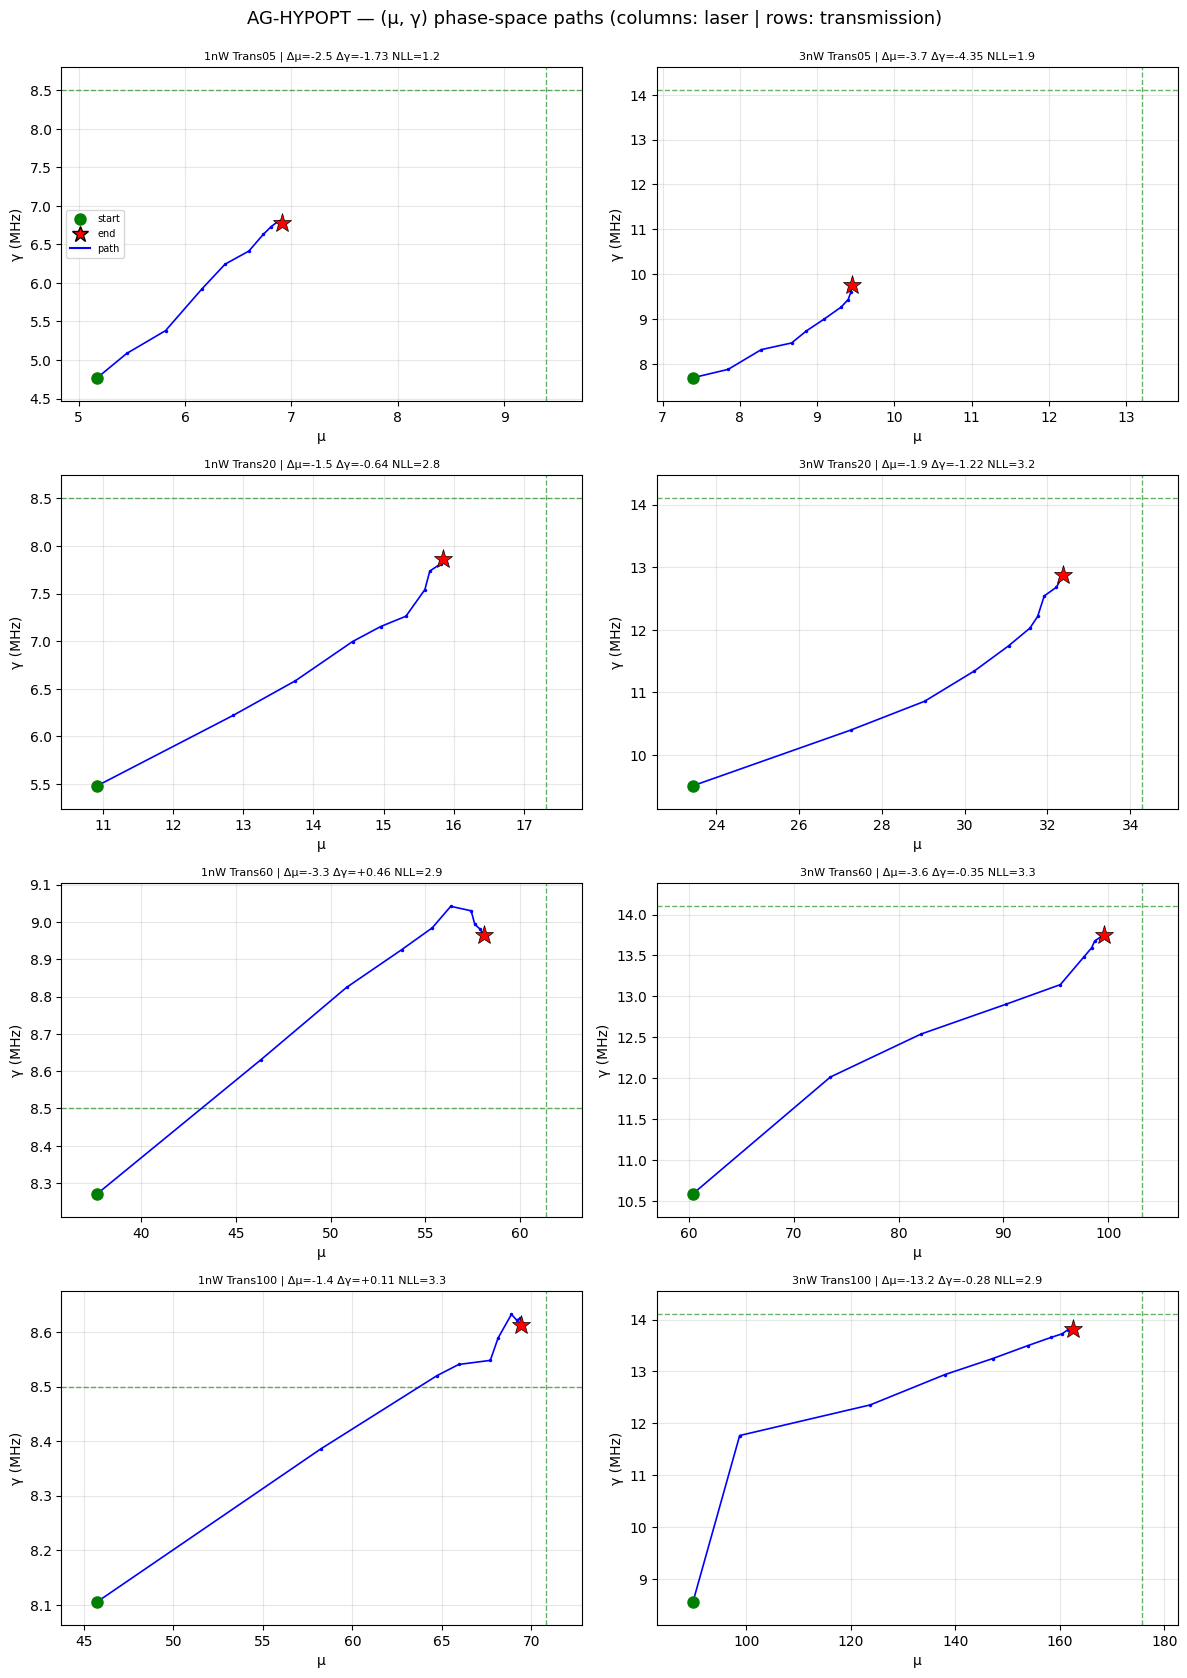

trial finished in 6.9 min
objective = 0.0203 ± 0.0081
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.91   -26.5 |     8.50    6.77   -20.3
1nW Trans20    17.32   15.85    -8.5 |     8.50    7.86    -7.6
1nW Trans60    61.37   58.08    -5.4 |     8.50    8.96    +5.5
1nW Trans100   70.82   69.44    -1.9 |     8.50    8.61    +1.3
3nW Trans05    13.20    9.45   -28.4 |    14.10    9.75   -30.8
3nW Trans20    34.28   32.38    -5.5 |    14.10   12.88    -8.7
3nW Trans60   103.20   99.63    -3.5 |    14.10   13.75    -2.5
3nW Trans100  175.71  162.46    -7.5 |    14.10   13.82    -2.0

μ: RMSE 5.326 (rel 14.6%, bias -3.886) | γ: RMSE 1.739 (rel 13.9%, bias -0.998)


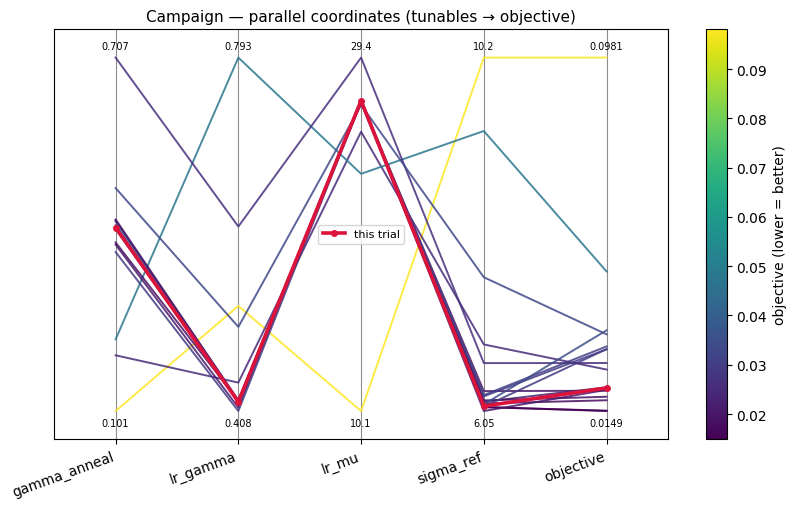

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 17 (sigma_ref 6.105, lr_mu 27.05, lr_gamma 0.418, gamma_anneal 0.415), the top-ei plateau draw, ran 6.9 min and scored 0.0203 +/- 0.0081. mu is 14.6% (the floor); gamma 13.9%, mid-range, dominated by 3nW Trans05 (-30.8%). This is the ninth run of the plateau config; across those runs the objective is 0.0149-0.0339 with mu fixed at 14.4-17.2% and gamma 9.5-21.4%, the whole range driven by the erratic low-count Trans05 scan. Trial 14 (0.0149) remains best; the campaign is fully converged on the plateau and the residual spread is irreducible single-scan noise.

**Summary:** Trial 17 (sigma_ref 6.105, lr_mu 27.05, lr_gamma 0.418, gamma_anneal 0.415) scored 0.0203 +/- 0.0081, a mid-range plateau result (mu 14.6%, gamma 13.9%); trial 14 (0.0149) remains best with the plateau fully converged.
**Key insight:** Repeating the plateau optimum now only re-samples the irreducible Trans05 gamma noise; mu is fixed at ~14.4-17.2% and no tunable changes this.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 17 (sigma_ref 6.105, lr_mu 27.05, lr_gamma 0.418, gamma_anneal 0.415) scored 0.0203 +/- 0.0081, a mid-range plateau result (mu 14.6%, gamma 13.9%); trial 14 (0.0149) remains best with the plateau fully converged.'
KEY_INSIGHT = 'Repeating the plateau optimum now only re-samples the irreducible Trans05 gamma noise; mu is fixed at ~14.4-17.2% and no tunable changes this.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_17 | current best: trial_14


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_18.ipynb. Open it and follow its cells from the top.
